# Transfer Learning: Klasifikasi Sampah dengan PyTorch (ResNet18)

**Dari CNN Scratch ke Transfer Learning**

Notebook ini merupakan pengembangan dari pendekatan CNN from-scratch sebelumnya. Kini kita memanfaatkan **Transfer Learning** dengan model **ResNet18** yang sudah dilatih pada dataset ImageNet (1,2 juta gambar, 1000 kelas) untuk mengklasifikasikan gambar sampah ke dalam 6 kategori sesuai dataset **TrashType_Image_Dataset**: **cardboard, glass, metal, paper, plastic, trash**.

Alur Transfer Learning:

```
Pre-trained ResNet18 (ImageNet)
  -> Freeze Convolutional Layers (Feature Extractor)
  -> Ganti FC Layer terakhir -> Output 6 Kelas
  -> Fine-tuning pada dataset sampah
```

---

## Mengapa Transfer Learning?

| Aspek | CNN from Scratch | Transfer Learning |
|---|---|---|
| Data yang dibutuhkan | Banyak (>10K) | Sedikit bisa cukup (<1K) |
| Waktu training | Lama | Lebih cepat |
| Akurasi awal | Rendah | Lebih tinggi |
| Fitur yang dipelajari | Dari awal | Memanfaatkan fitur ImageNet |

---

## Struktur Dataset

```
TrashType_Image_Dataset/
├── cardboard/
├── glass/
├── metal/
├── paper/
├── plastic/
└── trash/
```

Sesuaikan variabel `DATASET_DIR` agar menunjuk ke folder `TrashType_Image_Dataset`.


## 0. Setup & Import Library

Selain library PyTorch standar, kita menggunakan `torchvision.models` untuk mengakses ResNet18 yang sudah pre-trained.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Menggunakan device:", device)


Menggunakan device: cpu


In [2]:
# =========================================
# UBAH PATH INI sesuai lokasi dataset kamu
# =========================================
DATASET_DIR = "dataset/TrashType_Image_Dataset"   # folder berisi 6 subfolder kelas

# ResNet18 membutuhkan input 224x224 (ukuran standar ImageNet)
IMG_SIZE   = 224
BATCH_SIZE = 32


---
## STEP 1/6 — Input & Preprocessing: Sesuaikan dengan ResNet18

ResNet18 dilatih pada ImageNet dengan gambar berukuran **224×224** dan dinormalisasi menggunakan mean dan std spesifik ImageNet. Agar transfer knowledge bekerja optimal, kita **harus menggunakan normalisasi yang sama** saat melatih model kita.

Selain itu, kita terapkan **Data Augmentation** pada data train untuk memperkaya variasi data:
- **RandomHorizontalFlip**: membalik gambar secara horizontal
- **RandomRotation**: rotasi acak ±15 derajat
- **ColorJitter**: variasi kecerahan & kontras

Data val/test hanya di-resize dan dinormalisasi (tanpa augmentasi) agar evaluasi konsisten.


In [3]:
# Normalisasi ImageNet (WAJIB dipakai agar bobot pre-trained bekerja optimal)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Transform untuk TRAINING (dengan augmentasi)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Transform untuk VALIDASI & TEST (tanpa augmentasi)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("Transform training  :", train_transform)
print("\nTransform val/test  :", val_test_transform)


Transform training  : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Transform val/test  : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [4]:
# Load dataset dengan train_transform untuk eksplorasi visual
full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=train_transform)

class_names  = full_dataset.classes
num_classes  = len(class_names)
print("Kelas terdeteksi :", class_names)
print("Jumlah total gambar:", len(full_dataset))


Kelas terdeteksi : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'tesfolder', 'trash']
Jumlah total gambar: 2548


In [5]:
# Split indeks: 80% train / 10% val / 10% test
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)
n_test  = n_total - n_train - n_val

indices       = list(range(n_total))
random.shuffle(indices)
train_indices = indices[:n_train]
val_indices   = indices[n_train:n_train + n_val]
test_indices  = indices[n_train + n_val:]

# Dataset dengan transform berbeda untuk train vs val/test
train_dataset_raw = datasets.ImageFolder(root=DATASET_DIR, transform=train_transform)
valtest_dataset   = datasets.ImageFolder(root=DATASET_DIR, transform=val_test_transform)

from torch.utils.data import Subset
train_set = Subset(train_dataset_raw, train_indices)
val_set   = Subset(valtest_dataset,   val_indices)
test_set  = Subset(valtest_dataset,   test_indices)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")


Train: 2038 | Val: 254 | Test: 256


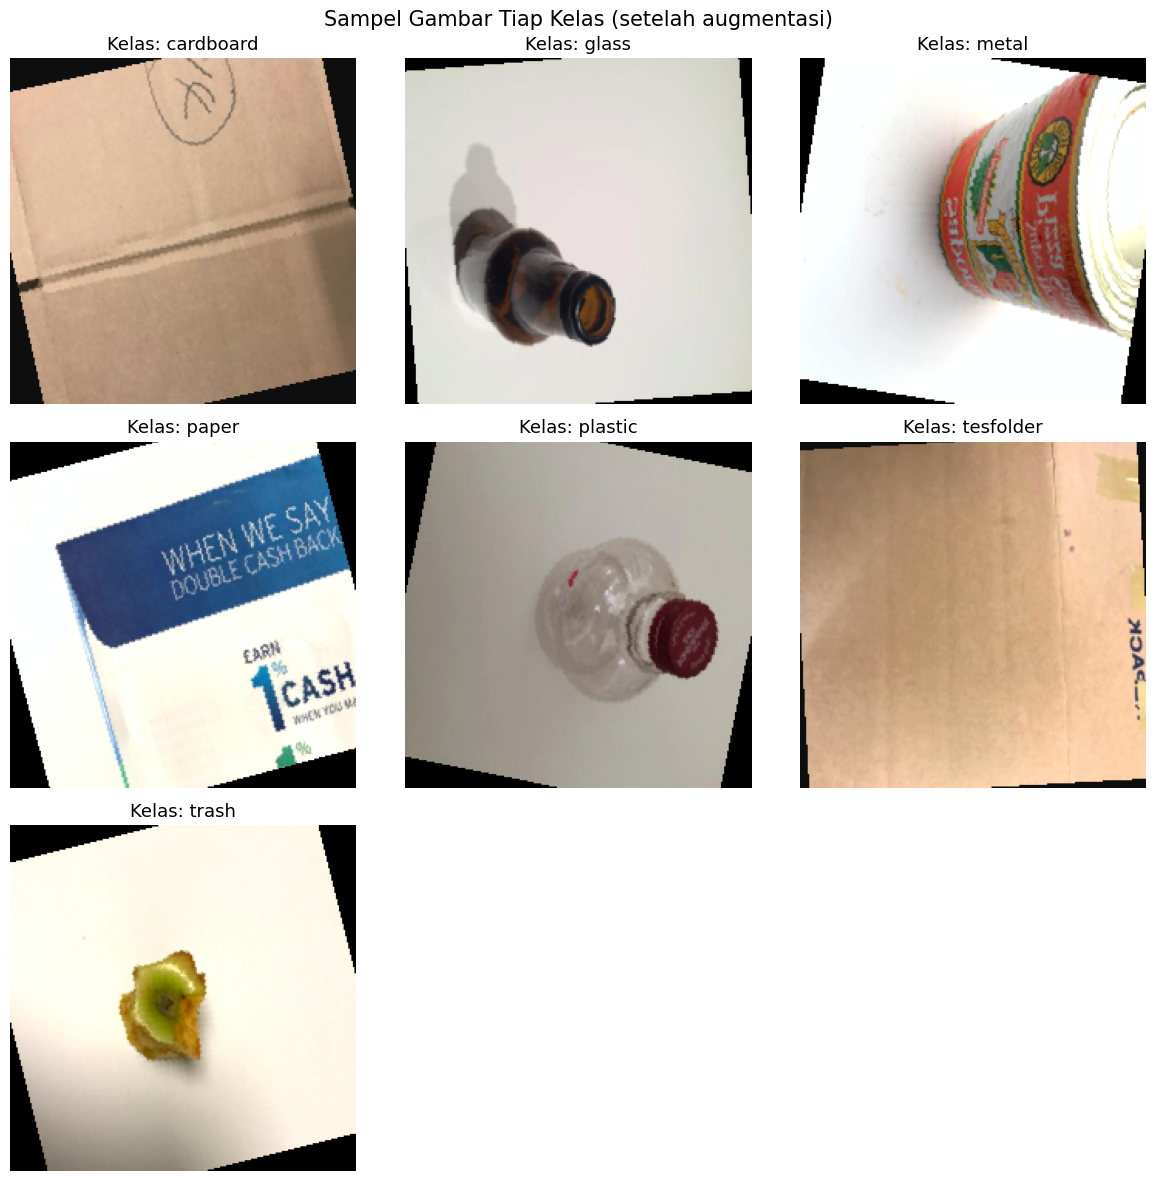

In [6]:
# Visualisasi sampel gambar dari tiap kelas
def imshow_imagenet(img_tensor):
    """Un-normalize dari normalisasi ImageNet untuk ditampilkan."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.numpy().transpose((1, 2, 0))
    img  = std * img + mean
    return np.clip(img, 0, 1)

# Ambil 1 gambar per kelas
shown = {}
for img, label in full_dataset:
    cls = class_names[label]
    if cls not in shown:
        shown[cls] = (img, label)
    if len(shown) == num_classes:
        break

n_shown = len(shown)
cols = 3
rows = (n_shown + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

for i, (cls, (img, label)) in enumerate(shown.items()):
    axes[i].imshow(imshow_imagenet(img))
    axes[i].set_title(f"Kelas: {cls}", fontsize=13)
    axes[i].axis("off")

# Sembunyikan axes kosong jika ada
for j in range(n_shown, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sampel Gambar Tiap Kelas (setelah augmentasi)", fontsize=15)
plt.tight_layout()
plt.show()


---
## STEP 2/6 — Transfer Learning: Apa itu ResNet18?

**ResNet18** (Residual Network 18 layer) adalah CNN yang dikembangkan oleh Microsoft Research dan memenangkan kompetisi ImageNet 2015. Keunggulan utamanya adalah **skip connections** (shortcut) yang memungkinkan gradient mengalir langsung melewati beberapa layer, mengatasi masalah *vanishing gradient* pada jaringan yang dalam.

```
Input (224x224x3)
  -> Conv1 (7x7, stride 2) -> BN -> ReLU -> MaxPool
  -> Layer1: 2x BasicBlock (64 filters)
  -> Layer2: 2x BasicBlock (128 filters) 
  -> Layer3: 2x BasicBlock (256 filters)
  -> Layer4: 2x BasicBlock (512 filters)
  -> AdaptiveAvgPool -> Flatten
  -> FC(512, 1000)  <-- ini yang kita GANTI ke FC(512, 6)
```

**BasicBlock** (unit dasar ResNet18):

```
Input
  |---> Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN
  |                                          |
  +-------------------(shortcut)-------------+
                                             |
                                           ReLU
                                           Output
```

Kita gunakan metode **Fixed Feature Extractor** + **Fine-tuning bertahap**:
1. **Fase 1**: Freeze semua layer konvolusi, latih hanya FC baru.
2. **Fase 2** (opsional): Unfreeze layer-layer terakhir untuk fine-tuning lebih dalam.


In [7]:
# Muat ResNet18 dengan bobot pre-trained ImageNet
weights = models.ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

# Tampilkan arsitektur asli
print("=== Arsitektur ResNet18 Asli ===")
print(model)


=== Arsitektur ResNet18 Asli ===
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=T

In [8]:
# Tampilkan detail layer terakhir yang akan diganti
print("Layer FC asli (output 1000 kelas ImageNet):")
print(model.fc)
print(f"  In features : {model.fc.in_features}")
print(f"  Out features: {model.fc.out_features}")


Layer FC asli (output 1000 kelas ImageNet):
Linear(in_features=512, out_features=1000, bias=True)
  In features : 512
  Out features: 1000


---
## STEP 3/6 — Modifikasi Model: Ganti Classifier

Langkah kunci Transfer Learning:

1. **Freeze** semua layer konvolusi agar bobotnya tidak berubah saat training.
2. **Ganti** layer `fc` terakhir dengan layer baru yang outputnya = 6 (jumlah kelas kita).
3. Hanya **parameter layer baru** yang dilatih pada fase pertama.

Visualisasi perubahan:

```
ResNet18 Pre-trained         ResNet18 (Versi Kita)
─────────────────────        ──────────────────────────────
Conv Layers (frozen)    →    Conv Layers (FROZEN)
         ↓                             ↓
  FC(512 → 1000)         →    FC(512 → 256) → ReLU → Dropout
                               FC(256 → 6)   ← output kita!
```


In [9]:
# ── Fase 1: Freeze semua parameter ──────────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ── Ganti FC layer terakhir ──────────────────────────────────────────────────
in_features = model.fc.in_features   # 512 untuk ResNet18

model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)       # output = 6 kelas
)

model = model.to(device)

# Verifikasi: hanya parameter fc baru yang dilatih
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
frozen      = total_params - trainable

print(f"Total parameter    : {total_params:,}")
print(f"Parameter dilatih  : {trainable:,}  ({trainable/total_params*100:.1f}%)")
print(f"Parameter di-freeze: {frozen:,}  ({frozen/total_params*100:.1f}%)")
print("\nLayer FC baru:")
print(model.fc)


Total parameter    : 11,309,639
Parameter dilatih  : 133,127  (1.2%)
Parameter di-freeze: 11,176,512  (98.8%)

Layer FC baru:
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=256, out_features=7, bias=True)
)


In [10]:
# Visualisasi: parameter mana yang dilatih vs frozen
layer_info = []
for name, param in model.named_parameters():
    layer_info.append({
        "layer": name,
        "trainable": param.requires_grad,
        "params": param.numel()
    })

frozen_layers    = [l for l in layer_info if not l["trainable"]]
trainable_layers = [l for l in layer_info if l["trainable"]]

print(f"Layer FROZEN    ({len(frozen_layers)} layers):")
for l in frozen_layers[:5]:
    print(f"  ✗ {l['layer']} ({l['params']:,} params)")
print(f"  ... ({len(frozen_layers)-5} layer lainnya)")

print(f"\nLayer TRAINABLE ({len(trainable_layers)} layers):")
for l in trainable_layers:
    print(f"  ✓ {l['layer']} ({l['params']:,} params)")


Layer FROZEN    (60 layers):
  ✗ conv1.weight (9,408 params)
  ✗ bn1.weight (64 params)
  ✗ bn1.bias (64 params)
  ✗ layer1.0.conv1.weight (36,864 params)
  ✗ layer1.0.bn1.weight (64 params)
  ... (55 layer lainnya)

Layer TRAINABLE (4 layers):
  ✓ fc.0.weight (131,072 params)
  ✓ fc.0.bias (256 params)
  ✓ fc.3.weight (1,792 params)
  ✓ fc.3.bias (7 params)


---
## STEP 4/6 — Training (Fixed Feature Extractor)

Karena layer konvolusi di-freeze, optimizer hanya memperbarui parameter layer `fc` baru. Ini membuat training **lebih cepat** dan **lebih stabil** karena fitur tingkat rendah (edges, textures) yang sudah dipelajari dari ImageNet tidak rusak.

Strategi yang digunakan:
- **Loss**: `CrossEntropyLoss` (sudah meng-handle Softmax internal)
- **Optimizer**: `Adam` hanya pada parameter yang `requires_grad=True`
- **Learning Rate Scheduler**: `ReduceLROnPlateau` — turunkan LR jika val_loss stagnan
- **Early Stopping**: hentikan training jika tidak ada perbaikan selama N epoch
- **Best Model Checkpoint**: simpan model terbaik berdasarkan val_accuracy


In [11]:
# Hanya optimalkan parameter yang trainable (FC baru)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

NUM_EPOCHS   = 15
PATIENCE     = 5      # early stopping
best_val_acc = 0.0
patience_cnt = 0
history      = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("=== Fase 1: Training Fixed Feature Extractor ===")
print(f"Hanya melatih layer FC ({sum(p.numel() for p in model.parameters() if p.requires_grad):,} parameter)\n")

for epoch in range(NUM_EPOCHS):
    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── Validasi ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_acc)

    # Best model checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model_phase1.pth")
        ckpt_mark = " ✓ SAVED"
        patience_cnt = 0
    else:
        patience_cnt += 1
        ckpt_mark = ""

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{ckpt_mark}")

    if patience_cnt >= PATIENCE:
        print(f"\nEarly stopping pada epoch {epoch+1}.")
        break

print(f"\nBest Val Accuracy (Fase 1): {best_val_acc:.4f}")


=== Fase 1: Training Fixed Feature Extractor ===
Hanya melatih layer FC (133,127 parameter)

Epoch [ 1/15] Train Loss: 1.3094 Acc: 0.5010 | Val Loss: 0.8734 Acc: 0.7047 ✓ SAVED
Epoch [ 2/15] Train Loss: 0.9090 Acc: 0.6629 | Val Loss: 0.6983 Acc: 0.7756 ✓ SAVED
Epoch [ 3/15] Train Loss: 0.8115 Acc: 0.7007 | Val Loss: 0.6068 Acc: 0.8071 ✓ SAVED
Epoch [ 4/15] Train Loss: 0.7466 Acc: 0.7414 | Val Loss: 0.6318 Acc: 0.8228 ✓ SAVED
Epoch [ 5/15] Train Loss: 0.7192 Acc: 0.7468 | Val Loss: 0.6042 Acc: 0.8346 ✓ SAVED
Epoch [ 6/15] Train Loss: 0.7246 Acc: 0.7395 | Val Loss: 0.5410 Acc: 0.8504 ✓ SAVED
Epoch [ 7/15] Train Loss: 0.6697 Acc: 0.7591 | Val Loss: 0.5373 Acc: 0.8268
Epoch [ 8/15] Train Loss: 0.6344 Acc: 0.7699 | Val Loss: 0.5119 Acc: 0.8425
Epoch [ 9/15] Train Loss: 0.6170 Acc: 0.7748 | Val Loss: 0.4754 Acc: 0.8583 ✓ SAVED
Epoch [10/15] Train Loss: 0.5626 Acc: 0.7934 | Val Loss: 0.4859 Acc: 0.8465
Epoch [11/15] Train Loss: 0.5764 Acc: 0.7910 | Val Loss: 0.4695 Acc: 0.8701 ✓ SAVED
Epoch [

---
## STEP 5/6 — Fine-tuning: Unfreeze Layer Terakhir

Setelah FC layer baru terlatih dengan baik, kita lakukan **Fine-tuning** dengan meng-unfreeze beberapa layer konvolusi terakhir (`layer4`). Ini memungkinkan fitur tingkat tinggi di layer akhir ResNet ikut menyesuaikan diri dengan karakteristik dataset sampah.

Penting: gunakan **learning rate yang sangat kecil** (1e-4) agar bobot pre-trained tidak rusak.

```
Layer          | Fase 1       | Fase 2 (Fine-tuning)
───────────────|──────────────|────────────────────
layer1-3       | FROZEN       | FROZEN
layer4         | FROZEN       | TRAINABLE (lr=1e-4)
fc (baru)      | TRAINABLE    | TRAINABLE (lr=1e-4)
```


In [12]:
# Load bobot terbaik dari Fase 1
model.load_state_dict(torch.load("best_model_phase1.pth", map_location=device))

# ── Handling Underfitting/Overfitting: Rebuild FC dengan Dropout lebih kuat ──
# Jika setelah Fase 1 gap train-val besar (underfitting), kita perlu kapasitas lebih.
# Dropout(0.5) ditambahkan sebagai pencegahan overfitting saat layer4 di-unfreeze.
in_features = model.fc[0].in_features if hasattr(model.fc[0], 'in_features') else 512

model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.BatchNorm1d(256),         # stabilkan distribusi aktivasi
    nn.ReLU(),
    nn.Dropout(0.5),             # dropout lebih agresif dari Fase 1 (0.4 -> 0.5)
    nn.Linear(256, num_classes)
)
model = model.to(device)

# Unfreeze layer4 ResNet18
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

trainable_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameter trainable pada Fine-tuning: {trainable_ft:,}")
print("Layer yang dilatih:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  ✓ {name}")


Parameter trainable pada Fine-tuning: 8,527,367
Layer yang dilatih:
  ✓ layer4.0.conv1.weight
  ✓ layer4.0.bn1.weight
  ✓ layer4.0.bn1.bias
  ✓ layer4.0.conv2.weight
  ✓ layer4.0.bn2.weight
  ✓ layer4.0.bn2.bias
  ✓ layer4.0.downsample.0.weight
  ✓ layer4.0.downsample.1.weight
  ✓ layer4.0.downsample.1.bias
  ✓ layer4.1.conv1.weight
  ✓ layer4.1.bn1.weight
  ✓ layer4.1.bn1.bias
  ✓ layer4.1.conv2.weight
  ✓ layer4.1.bn2.weight
  ✓ layer4.1.bn2.bias
  ✓ fc.0.weight
  ✓ fc.0.bias
  ✓ fc.1.weight
  ✓ fc.1.bias
  ✓ fc.4.weight
  ✓ fc.4.bias


In [13]:
# Fine-tuning optimizer dengan LR lebih kecil + weight decay (L2 regularization)
optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4    # L2 regularization: penalti bobot besar -> cegah overfitting
)
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode="max", factor=0.5, patience=3
)

NUM_EPOCHS_FT   = 10
PATIENCE_FT     = 4
best_val_acc_ft = 0.0
patience_cnt_ft = 0
history_ft      = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("=== Fase 2: Fine-tuning (layer4 + FC) ===")
print("Teknik anti-overfitting: Dropout(0.5) + BatchNorm + Weight Decay(1e-4)\n")

for epoch in range(NUM_EPOCHS_FT):
    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── Validasi ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct / val_total

    history_ft["train_loss"].append(train_loss)
    history_ft["train_acc"].append(train_acc)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_acc"].append(val_acc)

    scheduler_ft.step(val_acc)

    # Deteksi overfitting: warning jika train acc jauh di atas val acc
    gap = train_acc - val_acc
    gap_warn = f" ⚠ gap={gap:.3f}" if gap > 0.10 else ""

    if val_acc > best_val_acc_ft:
        best_val_acc_ft = val_acc
        torch.save(model.state_dict(), "best_model_finetune.pth")
        ckpt_mark = " ✓ SAVED"
        patience_cnt_ft = 0
    else:
        patience_cnt_ft += 1
        ckpt_mark = ""

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS_FT}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{ckpt_mark}{gap_warn}")

    if patience_cnt_ft >= PATIENCE_FT:
        print(f"\nEarly stopping fine-tuning pada epoch {epoch+1}.")
        break

print(f"\nBest Val Accuracy (Fine-tuning): {best_val_acc_ft:.4f}")


=== Fase 2: Fine-tuning (layer4 + FC) ===
Teknik anti-overfitting: Dropout(0.5) + BatchNorm + Weight Decay(1e-4)

Epoch [ 1/10] Train Loss: 1.3105 Acc: 0.5613 | Val Loss: 0.6286 Acc: 0.8583 ✓ SAVED
Epoch [ 2/10] Train Loss: 0.6879 Acc: 0.8067 | Val Loss: 0.4409 Acc: 0.9055 ✓ SAVED
Epoch [ 3/10] Train Loss: 0.4918 Acc: 0.8685 | Val Loss: 0.3819 Acc: 0.8937
Epoch [ 4/10] Train Loss: 0.3730 Acc: 0.9136 | Val Loss: 0.3599 Acc: 0.9016
Epoch [ 5/10] Train Loss: 0.2891 Acc: 0.9352 | Val Loss: 0.3301 Acc: 0.9016
Epoch [ 6/10] Train Loss: 0.2189 Acc: 0.9529 | Val Loss: 0.3552 Acc: 0.8937

Early stopping fine-tuning pada epoch 6.

Best Val Accuracy (Fine-tuning): 0.9055


---
## Visualisasi Hasil Training

Grafik menampilkan dua fase: Fixed Feature Extractor (Fase 1) dan Fine-tuning (Fase 2). Perhatikan bagaimana akurasi biasanya meningkat kembali pada Fase 2 karena layer4 ikut beradaptasi.


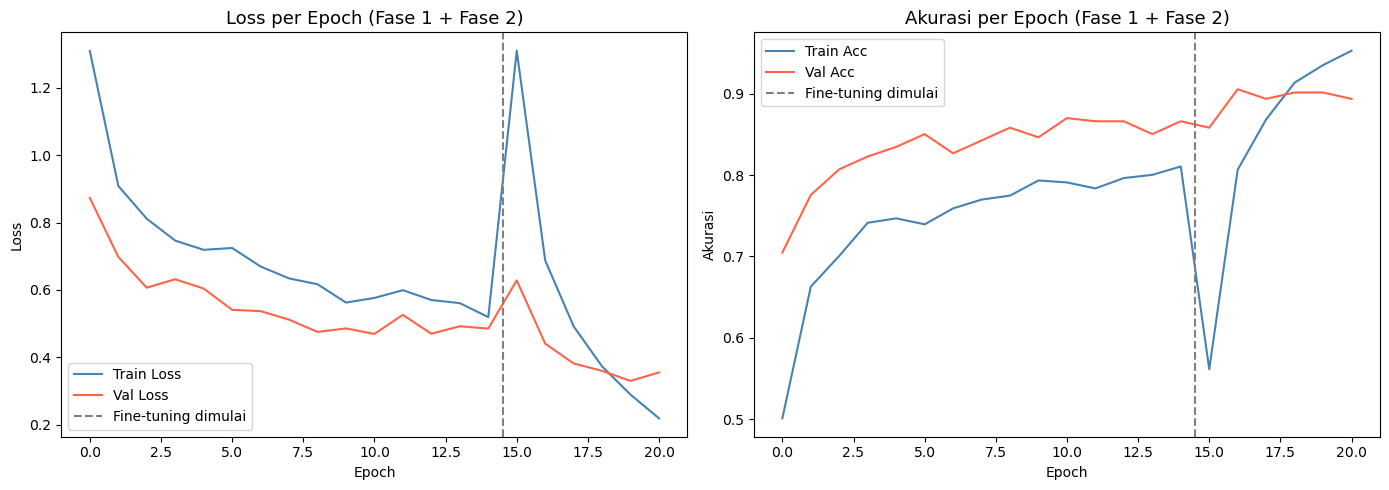

In [14]:
# Gabungkan history dua fase untuk visualisasi
all_train_loss = history["train_loss"] + history_ft["train_loss"]
all_val_loss   = history["val_loss"]   + history_ft["val_loss"]
all_train_acc  = history["train_acc"]  + history_ft["train_acc"]
all_val_acc    = history["val_acc"]    + history_ft["val_acc"]

n_phase1 = len(history["train_loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(all_train_loss, label="Train Loss", color="steelblue")
axes[0].plot(all_val_loss,   label="Val Loss",   color="tomato")
axes[0].axvline(n_phase1 - 0.5, color="gray", linestyle="--", label="Fine-tuning dimulai")
axes[0].set_title("Loss per Epoch (Fase 1 + Fase 2)", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(all_train_acc, label="Train Acc", color="steelblue")
axes[1].plot(all_val_acc,   label="Val Acc",   color="tomato")
axes[1].axvline(n_phase1 - 0.5, color="gray", linestyle="--", label="Fine-tuning dimulai")
axes[1].set_title("Akurasi per Epoch (Fase 1 + Fase 2)", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Akurasi")
axes[1].legend()

plt.tight_layout()
plt.show()


---
## STEP 6/6 — Evaluasi pada Test Set

Kita load model terbaik hasil fine-tuning, lalu evaluasi pada test set yang **belum pernah dilihat** selama training. Termasuk **confusion matrix** dan **classification report** per kelas.


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load model terbaik
model.load_state_dict(torch.load("best_model_finetune.pth", map_location=device))
model.eval()

all_preds, all_labels_list = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

test_acc = (np.array(all_preds) == np.array(all_labels_list)).mean()
print(f"Test Accuracy (Transfer Learning ResNet18): {test_acc:.4f} ({test_acc*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(all_labels_list, all_preds, target_names=class_names))


Test Accuracy (Transfer Learning ResNet18): 0.8359 (83.59%)

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.95      0.91      0.93        46
       glass       0.83      0.88      0.85        49
       metal       0.72      0.93      0.81        42
       paper       0.89      0.93      0.91        54
     plastic       0.78      0.78      0.78        46
   tesfolder       0.00      0.00      0.00         3
       trash       1.00      0.25      0.40        16

    accuracy                           0.84       256
   macro avg       0.74      0.67      0.67       256
weighted avg       0.84      0.84      0.82       256



/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

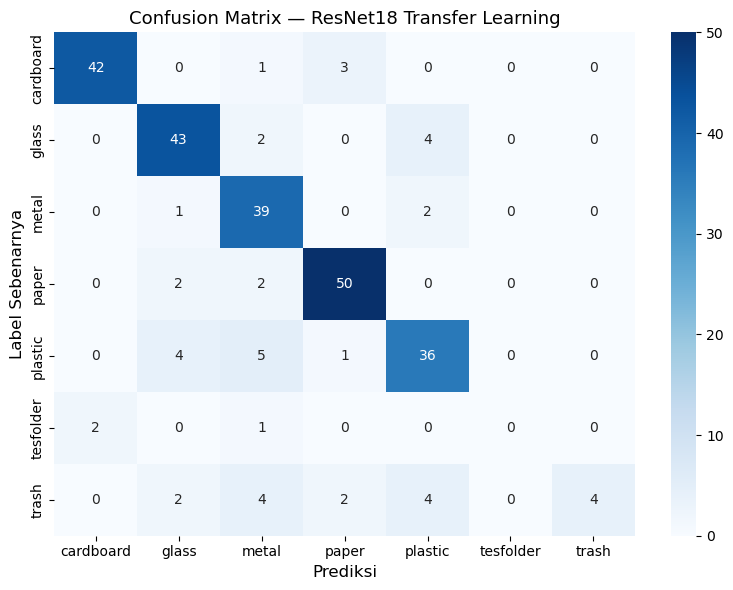

In [16]:
# Confusion Matrix
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediksi", fontsize=12)
plt.ylabel("Label Sebenarnya", fontsize=12)
plt.title("Confusion Matrix — ResNet18 Transfer Learning", fontsize=13)
plt.tight_layout()
plt.show()


---
## Inferensi: Prediksi dengan Probabilitas (Softmax)

Demonstrasi prediksi pada 1 gambar acak dari test set. Softmax diterapkan secara eksplisit untuk mendapatkan distribusi probabilitas tiap kelas.


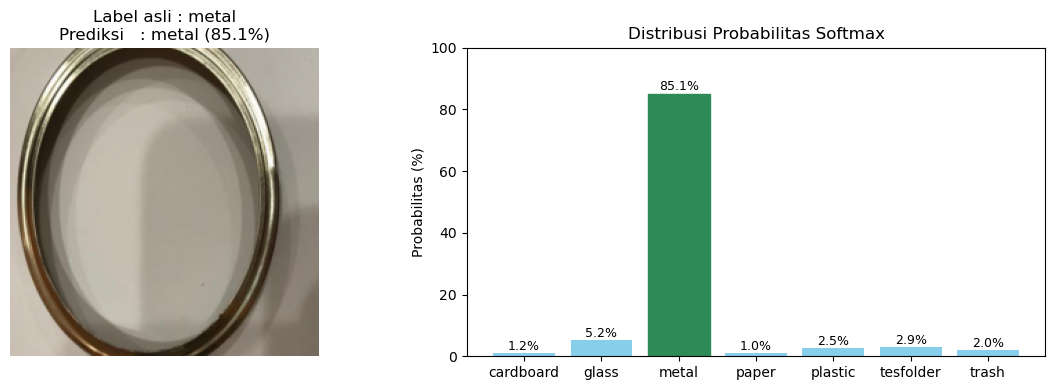

Total probabilitas (harus = 100%): 100.0 %


In [17]:
def predict_image(model, image_tensor, class_names):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        logits = model(image_tensor)
        probs  = F.softmax(logits, dim=1).cpu().numpy()[0]
    return probs

# Ambil 1 sample acak dari test set
sample_idx               = random.randint(0, len(test_set) - 1)
img_tensor, true_label   = test_set[sample_idx]

probs      = predict_image(model, img_tensor, class_names)
pred_label = np.argmax(probs)

# Gambar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(imshow_imagenet(img_tensor))
axes[0].set_title(
    f"Label asli : {class_names[true_label]}\n"
    f"Prediksi   : {class_names[pred_label]} ({probs[pred_label]*100:.1f}%)",
    fontsize=12
)
axes[0].axis("off")

# Bar chart probabilitas
bars = axes[1].bar(class_names, probs * 100, color="skyblue")
bars[pred_label].set_color("seagreen")
axes[1].set_ylabel("Probabilitas (%)")
axes[1].set_title("Distribusi Probabilitas Softmax", fontsize=12)
axes[1].set_ylim(0, 100)
for i, p in enumerate(probs * 100):
    axes[1].text(i, p + 1, f"{p:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Total probabilitas (harus = 100%):", round(probs.sum() * 100, 2), "%")


---
## Tes Model dengan Gambar Baru (Upload Sendiri)

Uji model menggunakan foto sampah yang **belum pernah dilihat** oleh model.

Cara pakai:
1. Siapkan file gambar (jpg/png).
2. Ubah variabel `TEST_IMAGE_PATH` ke path file tersebut.
3. Jalankan cell — prediksi dan probabilitas tiap kelas akan ditampilkan.


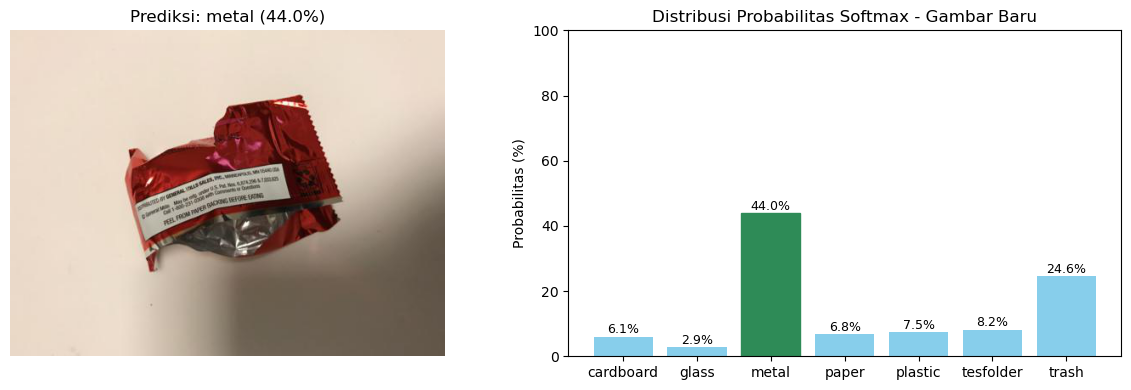

cardboard : 6.05%
glass     : 2.85%
metal     : 43.95%
paper     : 6.82%
plastic   : 7.50%
tesfolder : 8.18%
trash     : 24.64%


In [18]:
from PIL import Image

TEST_IMAGE_PATH = "trash_003.jpg"  # <-- ganti dengan path foto kamu

def predict_new_image(path, model, class_names):
    img        = Image.open(path).convert("RGB")
    img_tensor = val_test_transform(img)   # pakai transform val (tanpa augmentasi)

    model.eval()
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
        probs  = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = np.argmax(probs)
    return img, probs, pred_idx

img, probs, pred_idx = predict_new_image(TEST_IMAGE_PATH, model, class_names)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img)
axes[0].set_title(f"Prediksi: {class_names[pred_idx]} ({probs[pred_idx]*100:.1f}%)", fontsize=12)
axes[0].axis("off")

bars = axes[1].bar(class_names, probs * 100, color="skyblue")
bars[pred_idx].set_color("seagreen")
axes[1].set_ylabel("Probabilitas (%)")
axes[1].set_title("Distribusi Probabilitas Softmax - Gambar Baru")
axes[1].set_ylim(0, 100)
for i, p in enumerate(probs * 100):
    axes[1].text(i, p + 1, f"{p:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

for cls, p in zip(class_names, probs):
    print(f"{cls:10s}: {p*100:.2f}%")


### Tes Banyak Gambar Sekaligus (Batch)

Gunakan cell berikut untuk menguji semua gambar dalam satu folder.

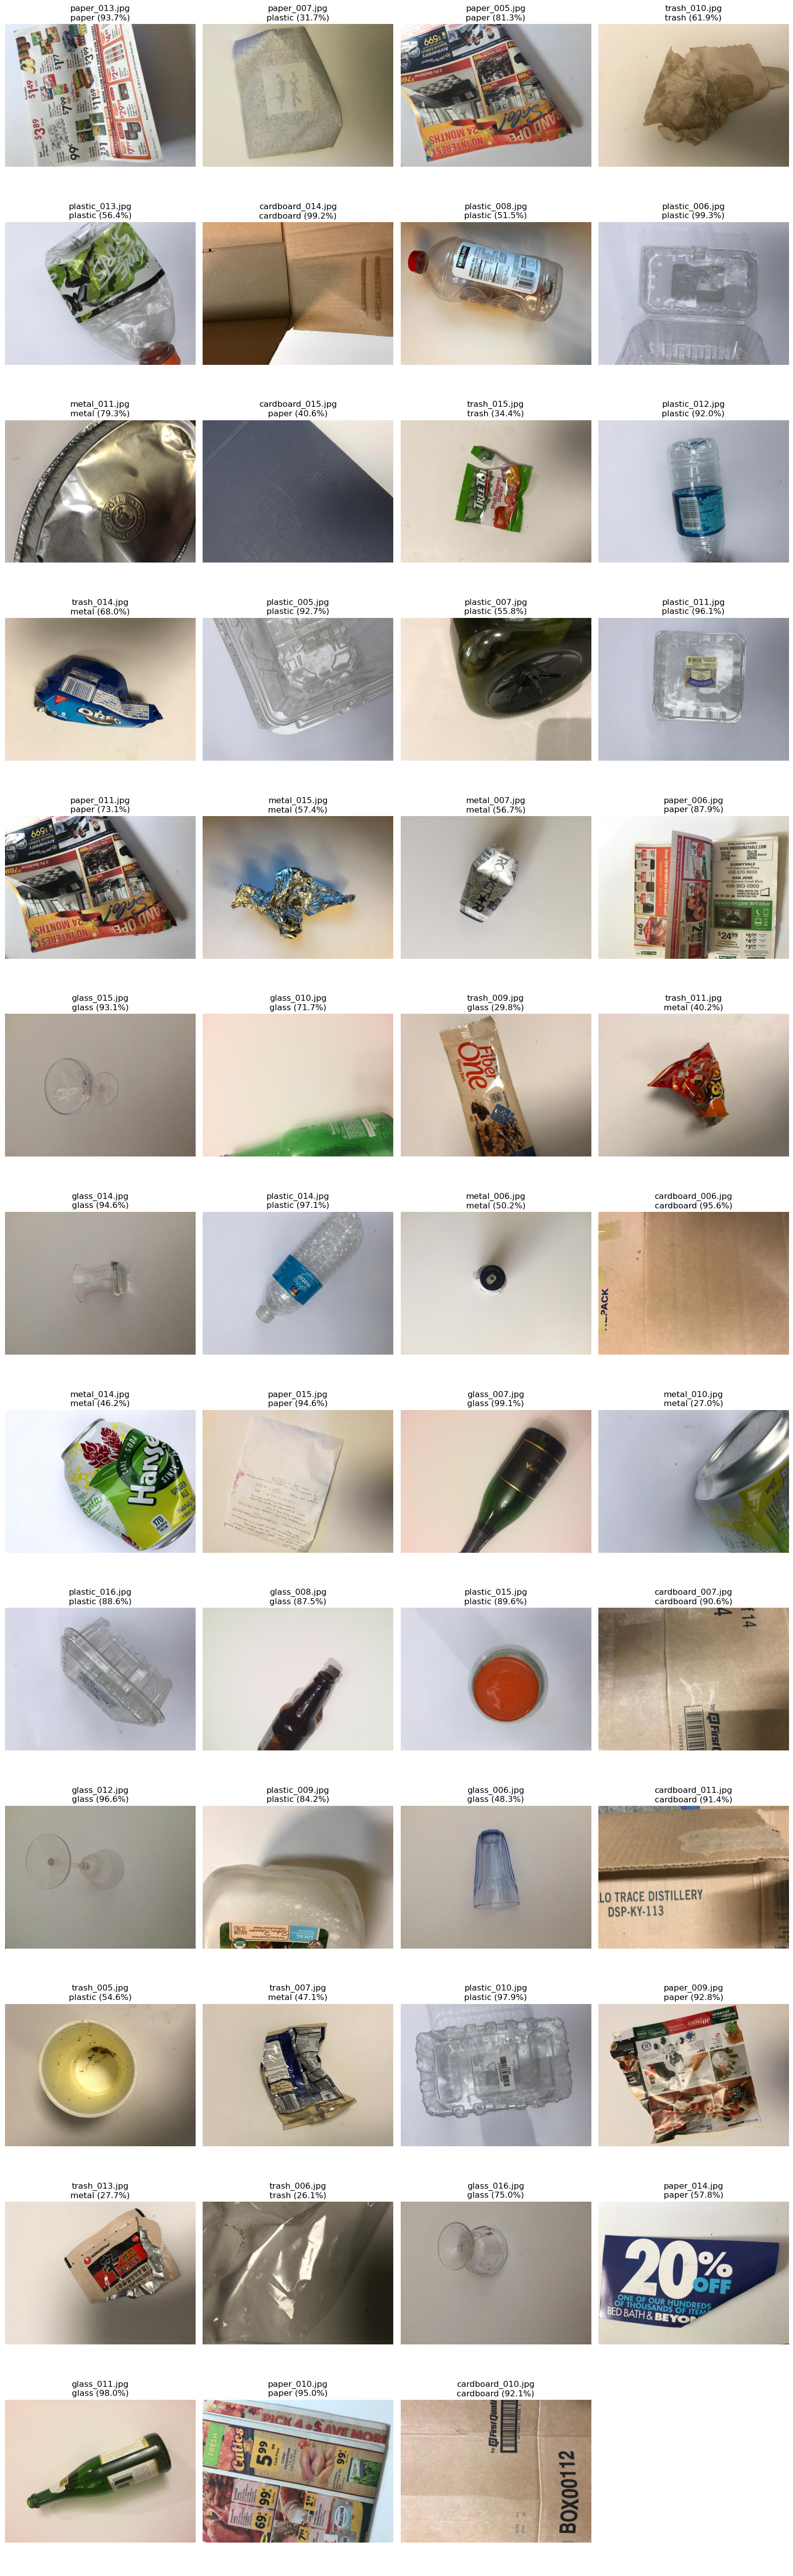

In [19]:
import glob

TEST_FOLDER  = "tesfolder"   # <-- folder berisi beberapa gambar

image_paths = glob.glob(os.path.join(TEST_FOLDER, "*"))
image_paths = [p for p in image_paths if p.lower().endswith((".jpg", ".jpeg", ".png"))]

if len(image_paths) == 0:
    print(f"Tidak ada gambar ditemukan di folder '{TEST_FOLDER}'.")
else:
    n    = len(image_paths)
    cols = min(4, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, path in enumerate(image_paths):
        img, probs, pred_idx = predict_new_image(path, model, class_names)
        axes[i].imshow(img)
        axes[i].set_title(
            f"{os.path.basename(path)}\n{class_names[pred_idx]} ({probs[pred_idx]*100:.1f}%)"
        )
        axes[i].axis("off")

    for j in range(len(image_paths), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


---
## Menyimpan Model Final

Simpan bobot model terbaik hasil fine-tuning.

In [20]:
torch.save(model.state_dict(), "trash_resnet18_transfer.pth")
print("Model disimpan sebagai trash_resnet18_transfer.pth")

# Cara load kembali:
# from torchvision import models
# model_loaded = models.resnet18(weights=None)
# model_loaded.fc = nn.Sequential(
#     nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes)
# )
# model_loaded.load_state_dict(torch.load("trash_resnet18_transfer.pth", map_location=device))
# model_loaded.to(device)
# model_loaded.eval()


Model disimpan sebagai trash_resnet18_transfer.pth


---
## Analisis Overfitting Pasca Training

Setelah kedua fase selesai, kita analisis apakah terjadi overfitting dengan melihat **gap antara Train Accuracy dan Val Accuracy**.

| Kondisi | Ciri | Tindakan |
|---|---|---|
| **Underfitting** | Val Acc > Train Acc (seperti Fase 1 kita) | Unfreeze lebih banyak layer, tambah kapasitas |
| **Seimbang (ideal)** | Train Acc ≈ Val Acc, keduanya tinggi | Lanjut evaluasi test |
| **Overfitting** | Train Acc >> Val Acc (gap > 10%) | Tingkatkan Dropout, kurangi epoch, augmentasi lebih banyak |

Teknik yang sudah diterapkan pada notebook ini:
- **Dropout(0.5)** pada FC layer — menonaktifkan 50% neuron secara acak saat training
- **BatchNorm1d** — normalisasi distribusi aktivasi, efek regularisasi ringan
- **Weight Decay (L2) = 1e-4** — penalti pada bobot besar di optimizer Adam
- **Early Stopping** — hentikan training saat val_acc stagnan
- **Data Augmentation** — RandomHorizontalFlip, RandomRotation, ColorJitter


In [21]:
# Analisis gap train vs val di Fase 2
print("=== Analisis Overfitting Fase 2 ===\n")
print(f"{'Epoch':>6} | {'Train Acc':>10} | {'Val Acc':>9} | {'Gap (T-V)':>10} | Status")
print("-" * 58)

for i, (ta, va) in enumerate(zip(history_ft["train_acc"], history_ft["val_acc"])):
    gap = ta - va
    if gap > 0.10:
        status = "⚠ OVERFITTING"
    elif gap < -0.05:
        status = "↓ underfitting"
    else:
        status = "✓ seimbang"
    print(f"{i+1:>6} | {ta:>10.4f} | {va:>9.4f} | {gap:>+10.4f} | {status}")

avg_gap = sum(t - v for t, v in zip(history_ft["train_acc"], history_ft["val_acc"])) / len(history_ft["train_acc"])
print(f"\nRata-rata gap Fase 2: {avg_gap:+.4f}")
if avg_gap > 0.10:
    print("-> Model mengalami OVERFITTING. Coba: naikkan Dropout, kurangi epoch, lebih banyak augmentasi.")
elif avg_gap < -0.05:
    print("-> Model masih UNDERFITTING. Coba: unfreeze layer3 juga, tambah epoch.")
else:
    print("-> Model dalam kondisi SEIMBANG. Training berhasil!")


=== Analisis Overfitting Fase 2 ===

 Epoch |  Train Acc |   Val Acc |  Gap (T-V) | Status
----------------------------------------------------------
     1 |     0.5613 |    0.8583 |    -0.2969 | ↓ underfitting
     2 |     0.8067 |    0.9055 |    -0.0988 | ↓ underfitting
     3 |     0.8685 |    0.8937 |    -0.0252 | ✓ seimbang
     4 |     0.9136 |    0.9016 |    +0.0121 | ✓ seimbang
     5 |     0.9352 |    0.9016 |    +0.0337 | ✓ seimbang
     6 |     0.9529 |    0.8937 |    +0.0592 | ✓ seimbang

Rata-rata gap Fase 2: -0.0527
-> Model masih UNDERFITTING. Coba: unfreeze layer3 juga, tambah epoch.
